<a href="https://colab.research.google.com/github/hongxu-yn/Drought-monitoring-and-assessment/blob/main/src/%E7%A0%94%E7%A9%B6%E5%8C%BA%E6%A6%82%E5%86%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 初始化

In [1]:
from google.colab import drive
drive.mount('/content/drive')
png_dir="/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/结果与分析"
!apt-get update -qq
!apt-get install -y fonts-freefont-ttf
!pip install cartopy
!pip install adjustText
!pip install netcdf4 h5netcdf scipy
!apt-get install -y ttf-mscorefonts-installer

Mounted at /content/drive
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-freefont-ttf
0 upgraded, 1 newly installed, 0 to remove and 80 not upgraded.
Need to get 2,388 kB of archives.
After this operation, 6,653 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-freefont-ttf all 20120503-10build1 [2,388 kB]
Fetched 2,388 kB in 0s (22.7 MB/s)
Selecting previously unselected package fonts-freefont-ttf.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-freefont-ttf_20120503-10build1_all.deb ...
Unpacking fonts-freefont-ttf (20120503-10build1) ...
Setting up fonts-freefont-ttf (20120503-10build1) .

In [ ]:
import geopandas as gpd
import os
import zipfile

# 1. 读取 GeoJSON 文件
input_file = '/content/drive/MyDrive/gis/china/中国_省.geojson'
gdf = gpd.read_file(input_file)

# 2. 核心修正：只筛选出 'Polygon' 和 'MultiPolygon'
# 过滤掉 LineString, MultiLineString 和 Point
gdf_polygons = gdf[gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])]

print(f"原始记录: {len(gdf)} 条")
print(f"过滤后（面状记录）: {len(gdf_polygons)} 条")
print(f"被剔除的非面状记录: {len(gdf) - len(gdf_polygons)} 条")

# 3. 导出为 SHP
output_dir = "./china_county_shp"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 建议使用 'GBK' 编码，因为国内很多 GIS 软件（如 ArcGIS）默认对 UTF-8 的 SHP 支持不佳
gdf_polygons.to_file(os.path.join(output_dir, "China_Counties.shp"),
                     driver='ESRI Shapefile',
                     encoding='utf-8')

print("✅ 转换完成！非面状要素已被自动剔除，SHP 已生成。")

原始记录: 42 条
过滤后（面状记录）: 34 条
被剔除的非面状记录: 8 条
✅ 转换完成！非面状要素已被自动剔除，SHP 已生成。


成功读取: china_province.shp，编码: utf-8
几何类型: ['MultiPolygon' 'Polygon']
范围: [ 73.498962   3.832541 135.087387  53.558498]
成功读取: 中国范围.shp，编码: utf-8
几何类型: ['LineString']
范围: [ 73.5011421    3.40847731 135.08851148  53.56090105]
成功读取: boua_d.shp，编码: utf-8
几何类型: ['Polygon' 'MultiPolygon']
范围: [ 97.52727829  21.1444331  106.19695792  29.22528598]
成功读取: boua_s.shp，编码: utf-8
几何类型: ['Polygon']
范围: [ 97.52727829  21.1444331  106.19695792  29.22528598]
未检测到 gdf_polygons，左图使用 china_province.shp。


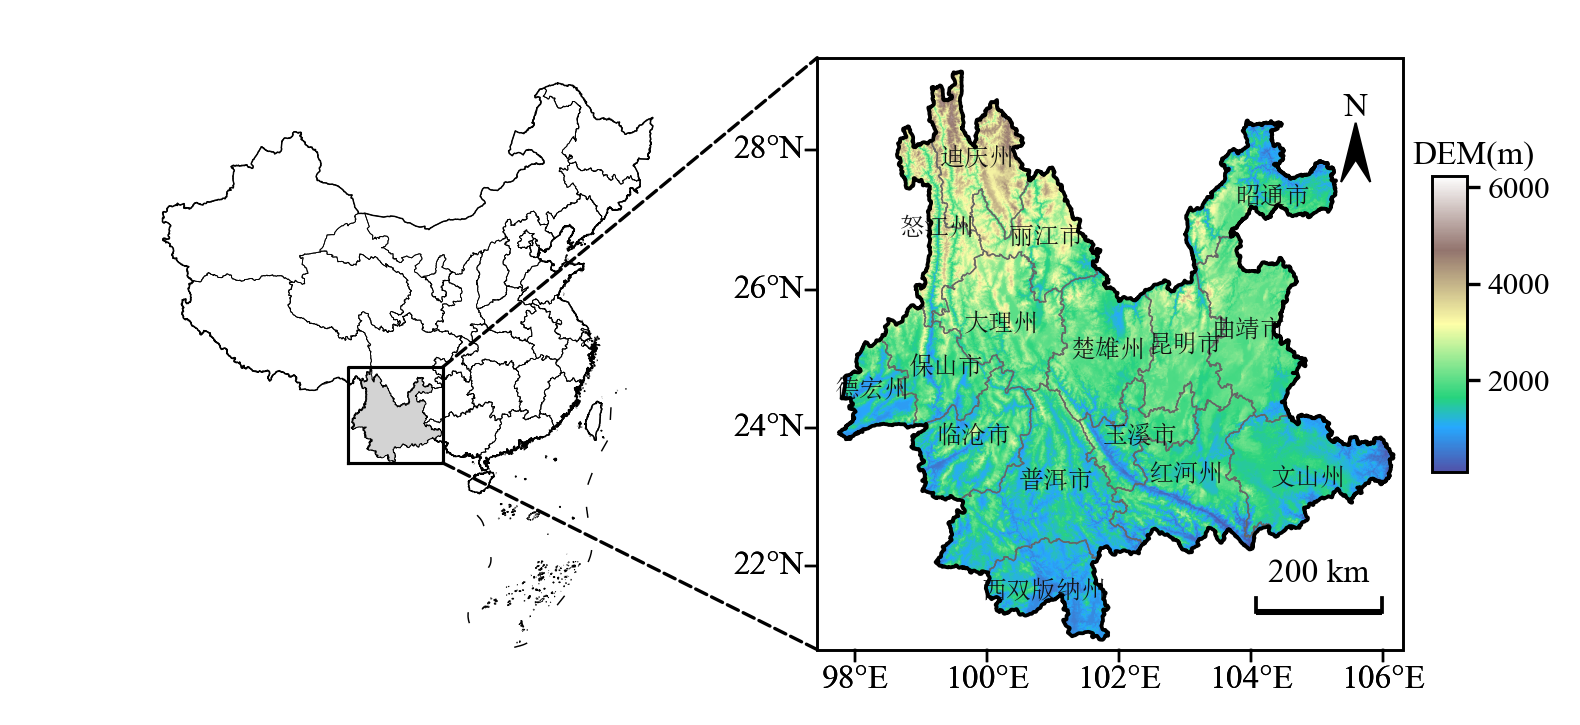

PNG saved to: /content/drive/MyDrive/Drought-monitoring-and-assessment/figures/Fig1_study_area_SCI_Albers_cn_outline.png
PDF saved to: /content/drive/MyDrive/Drought-monitoring-and-assessment/figures/Fig1_study_area_SCI_Albers_cn_outline.pdf


In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import geopandas as gpd
from pathlib import Path
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.mask import mask

project_dir = Path("/content/drive/MyDrive/Drought-monitoring-and-assessment")
fig_dir = project_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# =====================================================
# 字体设置
# =====================================================
font_dir = Path("/content/drive/MyDrive/fonts")
font_en_path = font_dir / "TimesNewRoman.ttf"
font_zh_path = font_dir / "SimSun.ttf"

if not font_en_path.exists():
    raise FileNotFoundError(f"未找到英文字体: {font_en_path}")
if not font_zh_path.exists():
    raise FileNotFoundError(f"未找到中文字体: {font_zh_path}")

fm.fontManager.addfont(str(font_en_path))
fm.fontManager.addfont(str(font_zh_path))

font_en = fm.FontProperties(fname=str(font_en_path))
font_zh = fm.FontProperties(fname=str(font_zh_path))
font_en_name = font_en.get_name()

mpl.rcParams.update({
    "font.family": font_en_name,
    "font.serif": [font_en_name],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "font.size": 8.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.7,
    "savefig.facecolor": "white",
    "figure.facecolor": "white"
})

# =====================================================
# 3. 安全读取 Shapefile
# =====================================================
def read_shp_safely(shp_path, target_crs="EPSG:4326", default_crs="EPSG:4326"):
    shp_path = Path(shp_path)

    if not shp_path.exists():
        raise FileNotFoundError(f"未找到矢量文件: {shp_path}")

    encodings = ["utf-8", "GB18030", "GBK"]
    last_error = None

    for enc in encodings:
        try:
            try:
                gdf = gpd.read_file(shp_path, engine="pyogrio", encoding=enc)
            except Exception:
                gdf = gpd.read_file(shp_path, encoding=enc)

            gdf = gdf[
                gdf.geometry.notna() & (~gdf.geometry.is_empty)
            ].copy()

            if gdf.empty:
                raise ValueError(f"{shp_path.name} 读取后为空，请检查文件是否完整。")

            if gdf.crs is None:
                print(f"提示：{shp_path.name} 未检测到 CRS，已默认设置为 {default_crs}")
                gdf = gdf.set_crs(default_crs)

            gdf = gdf.to_crs(target_crs)

            # 只修复面要素，不修复线要素
            poly_mask = gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
            if poly_mask.any():
                gdf.loc[poly_mask, "geometry"] = gdf.loc[poly_mask, "geometry"].buffer(0)

            gdf = gdf[
                gdf.geometry.notna() & (~gdf.geometry.is_empty)
            ].copy()

            if gdf.empty:
                raise ValueError(
                    f"{shp_path.name} 几何修复后为空。"
                    f"该文件可能是线要素，不能整体使用 buffer(0)。"
                )

            bounds = np.array(gdf.total_bounds, dtype=float)
            if not np.all(np.isfinite(bounds)):
                raise ValueError(
                    f"{shp_path.name} 的 total_bounds 无效: {bounds}。\n"
                    f"几何类型为: {gdf.geometry.geom_type.unique()}"
                )

            print(f"成功读取: {shp_path.name}，编码: {enc}")
            print(f"几何类型: {gdf.geometry.geom_type.unique()}")
            print(f"范围: {bounds}")

            return gdf

        except Exception as e:
            last_error = e

    raise RuntimeError(f"读取失败: {shp_path}\n最后一次错误为:\n{last_error}")


def projected_aspect(proj, extent):
    lon_min, lon_max, lat_min, lat_max = extent
    lons = np.array([lon_min, lon_max, lon_max, lon_min])
    lats = np.array([lat_min, lat_min, lat_max, lat_max])
    pts = proj.transform_points(pc, lons, lats)
    xs = pts[:, 0]
    ys = pts[:, 1]
    return (xs.max() - xs.min()) / (ys.max() - ys.min())

def set_map_frame(ax, linewidth=0.7):
    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)
        spine.set_color("black")

def add_panel_label(ax, label, title, fontsize=9.5):
    ax.text(
        0.018, 0.982,
        f"{label} {title}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontproperties=font_en, fontsize=fontsize, fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.82, pad=1.2),
        zorder=100
    )

def add_manual_lonlat_ticks(ax, xticks, yticks, extent_lonlat, labelsize=8, tick_frac=0.014, xpad_frac=0.026, ypad_frac=0.022, linewidth=0.58):
    proj = ax.projection
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    xlen = x1 - x0
    ylen = y1 - y0

    tick_len_y = ylen * tick_frac
    tick_len_x = xlen * tick_frac
    lon_min, lon_max, lat_min, lat_max = extent_lonlat

    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ref_lat = lat_min
    for lon in xticks:
        x_tick, _ = proj.transform_point(lon, ref_lat, pc)
        if x0 <= x_tick <= x1:
            # 【修改点】：y0 + tick_len_y 改为 y0 - tick_len_y，使刻度线向下（向外）延伸
            ax.plot([x_tick, x_tick], [y0, y0 - tick_len_y], color="black", linewidth=linewidth, clip_on=False, zorder=90)
            ax.text(x_tick, y0 - ylen * xpad_frac, f"{int(lon)}°E", ha="center", va="top", fontproperties=font_en, fontsize=labelsize, clip_on=False, zorder=91)

    ref_lon = lon_min
    for lat in yticks:
        _, y_tick = proj.transform_point(ref_lon, lat, pc)
        if y0 <= y_tick <= y1:
            # 【修改点】：x0 + tick_len_x 改为 x0 - tick_len_x，使刻度线向左（向外）延伸
            ax.plot([x0, x0 - tick_len_x], [y_tick, y_tick], color="black", linewidth=linewidth, clip_on=False, zorder=90)
            ax.text(x0 - xlen * ypad_frac, y_tick, f"{int(lat)}°N", ha="right", va="center", fontproperties=font_en, fontsize=labelsize, clip_on=False, zorder=91)

def add_north(ax, labelsize=8, loc_x=0.915, loc_y=0.962, width=0.045, height=0.075, pad=0.108):
    minx, maxx = ax.get_xlim()
    miny, maxy = ax.get_ylim()
    xlen = maxx - minx
    ylen = maxy - miny

    left = [minx + xlen * (loc_x - width * 0.5), miny + ylen * (loc_y - pad)]
    right = [minx + xlen * (loc_x + width * 0.5), miny + ylen * (loc_y - pad)]
    top = [minx + xlen * loc_x, miny + ylen * (loc_y - pad + height)]
    center = [minx + xlen * loc_x, left[1] + (top[1] - left[1]) * 0.38]

    triangle = mpatches.Polygon([left, top, right, center], facecolor="black", edgecolor="black", linewidth=0.5, zorder=95)
    ax.add_patch(triangle)
    ax.text(x=minx + xlen * loc_x, y=miny + ylen * (loc_y - pad + height), s="N", fontsize=labelsize, fontproperties=font_en, ha="center", va="bottom", color="black", zorder=96)

def add_scalebar_albers(ax, length_km=200, location=(0.075, 0.075), linewidth=1.45, labelsize=8):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    xlen = x1 - x0
    ylen = y1 - y0

    start_x = x0 + xlen * location[0]
    start_y = y0 + ylen * location[1]

    scale_len = length_km * 1000.0
    tick_h = ylen * 0.012

    ax.plot([start_x, start_x + scale_len], [start_y-tick_h, start_y-tick_h], color="black", linewidth=linewidth, solid_capstyle="butt", zorder=95)
    ax.plot([start_x, start_x], [start_y - tick_h, start_y + tick_h], color="black", linewidth=0.9, zorder=95)
    ax.plot([start_x + scale_len, start_x + scale_len], [start_y - tick_h, start_y + tick_h], color="black", linewidth=0.9, zorder=95)
    ax.text(start_x + scale_len / 2, start_y + tick_h * 2.3, f"{length_km} km", ha="center", va="bottom", fontsize=labelsize, fontproperties=font_en, color="black", zorder=96)

def plot_outline_mixed_geometry(gdf, ax, color="black", linewidth=0.6, zorder=10):
    geom_type = gdf.geometry.geom_type
    poly_gdf = gdf[geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    line_gdf = gdf[geom_type.isin(["LineString", "MultiLineString"])].copy()

    if not poly_gdf.empty:
        poly_gdf.boundary.plot(ax=ax, color=color, linewidth=linewidth, zorder=zorder)
    if not line_gdf.empty:
        line_gdf.plot(ax=ax, color=color, linewidth=linewidth, zorder=zorder)

# =====================================================
# 1. 路径设置 (✅ 更新：加入省界和市界)
# =====================================================
china_shp = "/content/drive/MyDrive/gis/china/china_province.shp"
cn_outline_shp = "/content/drive/MyDrive/gis/china/中国范围.shp"
yn_shp = "/content/drive/MyDrive/gis/boua_s.shp"    # 云南省界
yn_d_shp = "/content/drive/MyDrive/gis/boua_d.shp"  # 云南市界
dem_tif = "/content/drive/MyDrive/gis/dem_wgs84.tif"
st_info="/content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/站点编号及信息_选定_1969-2025.xlsx"

out_png = fig_dir / "Fig1_study_area_SCI_Albers_cn_outline.png"
out_pdf = fig_dir / "Fig1_study_area_SCI_Albers_cn_outline.pdf"

china_gdf = read_shp_safely(china_shp)
cn_outline_gdf = read_shp_safely(cn_outline_shp)
yn_d_gdf = read_shp_safely(yn_d_shp)       # 省界
yn_gdf = read_shp_safely(yn_shp)       # 省界

try:
    left_gdf = gdf_polygons.to_crs("EPSG:4326")
    left_gdf = left_gdf[
        left_gdf.geometry.notna() & (~left_gdf.geometry.is_empty)
    ].copy()
    left_gdf["geometry"] = left_gdf["geometry"].buffer(0)
    print("左图使用已有的 gdf_polygons。")
except NameError:
    left_gdf = china_gdf.copy()
    print("未检测到 gdf_polygons，左图使用 china_province.shp。")

proj_albers = ccrs.AlbersEqualArea(
    central_longitude=105,
    central_latitude=35,
    standard_parallels=(25, 47)
)
pc = ccrs.PlateCarree()

albers_crs = (
    "+proj=aea +lat_0=35 +lon_0=105 "
    "+lat_1=25 +lat_2=47 "
    "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

left_gdf_albers = left_gdf.to_crs(albers_crs)
china_gdf_albers = china_gdf.to_crs(albers_crs)
cn_outline_albers = cn_outline_gdf.to_crs(albers_crs)

yn_gdf_albers = yn_gdf.to_crs(albers_crs)         # 投影后的省界
yn_d_gdf_albers = yn_d_gdf.to_crs(albers_crs)     # 投影后的市界
yn_gdf_albers = yn_gdf.to_crs(albers_crs) # 投影后的省外围轮廓

# 左图范围以“中国范围.shp”为准
cn_minx, cn_miny, cn_maxx, cn_maxy = cn_outline_gdf.total_bounds

china_buffer = 3
china_extent = [
    cn_minx , cn_maxx,
    cn_miny - china_buffer, cn_maxy + china_buffer
]

# 右图云南范围 (以省界 bbox 为准)
minx, miny, maxx, maxy = yn_gdf.total_bounds
yn_buffer = 0.1
yn_extent = [
    minx - yn_buffer, maxx + yn_buffer,
    miny - yn_buffer, maxy + yn_buffer
]


china_aspect = projected_aspect(proj_albers, china_extent)
yn_aspect = projected_aspect(proj_albers, yn_extent)

fig = plt.figure(figsize=(5, 3),dpi=300, facecolor="white")
gs = GridSpec(
    1, 2, figure=fig,
    left=0.070, right=0.985, bottom=0.05, top=0.95,
    wspace=0.01, width_ratios=[china_aspect, yn_aspect]
)
ax1 = fig.add_subplot(gs[0, 0], projection=proj_albers)
ax2 = fig.add_subplot(gs[0, 1], projection=proj_albers)

ax1.set_extent(china_extent, crs=pc)
plot_outline_mixed_geometry(cn_outline_albers, ax=ax1, color="black", linewidth=0.35, zorder=7)
left_gdf_albers.boundary.plot(ax=ax1, edgecolor="black", linewidth=0.2, zorder=2)
yn_gdf_albers.plot(ax=ax1, facecolor="lightgray", edgecolor="black", linewidth=0.2, zorder=8)
ax1.set_extent(china_extent, crs=pc)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.set_xticks([])
ax1.set_yticks([])

fig.canvas.draw()


# =====================================================
# 8.2 右图：云南研究区 (✅ 已更新：加入 DEM 图例)
# =====================================================
ax2.set_extent(yn_extent, crs=pc)

# 读取、按省界裁剪 DEM 并显示
with rasterio.open(dem_tif) as src:
    out_image, out_transform = mask(src, yn_gdf.geometry, crop=True, filled=False)
    dem_data = out_image[0]

    b = rasterio.transform.array_bounds(out_image.shape[1], out_image.shape[2], out_transform)
    dem_extent = [b[0], b[2], b[1], b[3]]

# 🟢 修改点 1：将 imshow 的结果赋值给 img 变量
img = ax2.imshow(
    dem_data,
    extent=dem_extent,
    transform=pc,
    cmap="terrain",
    origin="upper",
    zorder=1.5,
    alpha=0.85
)

# 绘制市级边界 (内部透明)
yn_d_gdf_albers.plot(
    ax=ax2,
    facecolor="none",
    edgecolor="#666666",
    linewidth=0.32,
    zorder=2
)

# 顶层：绘制省级大边界
yn_gdf_albers.boundary.plot(
    ax=ax2,
    edgecolor="black",
    linewidth=0.9,
    zorder=5
)

ax2.set_extent(yn_extent, crs=pc)
set_map_frame(ax2, linewidth=0.70)

fig.canvas.draw()

add_manual_lonlat_ticks(
    ax=ax2,
    xticks=[98, 100, 102, 104, 106],
    yticks=[22, 24, 26, 28],
    extent_lonlat=yn_extent,
    labelsize=8, tick_frac=0.02, xpad_frac=0.026, ypad_frac=0.022, linewidth=0.58
)

# [x起点, y起点, 宽度, 高度] 是相对 ax2 的比例坐标 (0~1)
cax = ax2.inset_axes([1.05, 0.3, 0.06, 0.5])
cbar = plt.colorbar(img, cax=cax, orientation="vertical")

# 🟢 已更新：将图例标题修改为 "DEM(m)"
cbar.ax.set_title("DEM(m)", fontproperties=font_en, fontsize=8, pad=3,x=1.2,loc="center")
cbar.ax.tick_params(length=3, pad=2)
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(font_en)
    label.set_fontsize(7.5)
# 🟢 新增：智能读取属性表并显示州市名称
# 自动寻找你的 shp 文件中可能的名称字段

import re

# 🟢 新增的简化函数
def simplify_name(name):
    # 1. 强制转为字符串，并清除可能存在的特殊乱码字符(如'聽')和两端空格
    name = str(name).replace("聽", "").strip()

    # 3. 移除各少数民族名称及 "自治州" 后缀
    # 这条正则完美匹配云南的所有自治州后缀
    name = re.sub(r'(彝族|白族|傣族|景颇族|藏族|哈尼族|傈僳族|壮族|苗族|自治)+', '', name)

    return name

# 自动寻找你的 shp 文件中可能的名称字段 (我把 "州市名" 加到了第一位)
name_col = None
for col in ["州市名", "NAME", "name", "Name", "市", "地州市", "CNTY_NM", "市名", "CITY"]:
    if col in yn_d_gdf_albers.columns:
        name_col = col
        break

if name_col:
    for idx, row in yn_d_gdf_albers.iterrows():
        if row.geometry:
            pt = row.geometry.representative_point()

            # 🟢 获取原始名称，并调用简化函数
            raw_name = row[name_col]
            short_name = simplify_name(raw_name)

            ax2.text(
                pt.x, pt.y,
                short_name,              # 这里使用了简化后的名字
                ha="center", va="center",
                fontproperties=font_zh,  fontweight="bold",       # 🟢 关键修改：强制开启加粗
                fontsize=6,
                color="#111111",
                zorder=4
            )
else:
    print(f"⚠️ 警告: 未找到名称字段，无法显示州市名。当前包含的字段有: {list(yn_d_gdf_albers.columns)}")


ax2.set_extent(yn_extent, crs=pc)
set_map_frame(ax2, linewidth=0.70)

add_manual_lonlat_ticks(
    ax=ax2,
    xticks=[98, 100, 102, 104, 106],
    yticks=[22, 24, 26, 28],
    extent_lonlat=yn_extent,
    labelsize=8, tick_frac=0.02, xpad_frac=0.026, ypad_frac=0.022, linewidth=0.58
)

add_north(ax2, labelsize=8, loc_x=0.92, loc_y=0.80, width=0.05, height=0.1, pad=0.01)
add_scalebar_albers(ax=ax2, length_km=200, location=(0.75, 0.075), linewidth=1.45, labelsize=8)

fig.canvas.draw()


# =====================================================
# 8.3 绘制研究区范围框与连线 (放大效果)
# =====================================================
# 1. 获取右图(ax2)在 Albers 投影坐标系下的精确边界范围
ax2_x0, ax2_x1 = ax2.get_xlim()
ax2_y0, ax2_y1 = ax2.get_ylim()

# 2. 在左图(ax1)绘制该范围的矩形框
# 因为两图投影完全相同，所以无需 transform=pc，直接使用投影坐标系(data space)
bbox_x = [ax2_x0, ax2_x1, ax2_x1, ax2_x0, ax2_x0]
bbox_y = [ax2_y0, ax2_y0, ax2_y1, ax2_y1, ax2_y0]
ax1.plot(
    bbox_x, bbox_y,
    color="black",
    linewidth=0.75,
    zorder=10
)

# 3. 添加跨图连线：将左图框的【右侧两角】，连接到右图的【左侧两角】
# 右上角相连
con_top = mpatches.ConnectionPatch(
    xyA=(ax2_x1, ax2_y1), xyB=(0, 1),
    coordsA="data", coordsB="axes fraction",
    axesA=ax1, axesB=ax2,
    color="black", linewidth=0.8, linestyle="--", zorder=100, clip_on=False
)
# 右下角相连
con_bottom = mpatches.ConnectionPatch(
    xyA=(ax2_x1, ax2_y0), xyB=(0, 0),
    coordsA="data", coordsB="axes fraction",
    axesA=ax1, axesB=ax2,
    color="black", linewidth=0.8, linestyle="--", zorder=100, clip_on=False
)

ax1.add_artist(con_top)
ax1.add_artist(con_bottom)
# =====================================================
# 9. 保存
# =====================================================
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf, dpi=600, bbox_inches="tight")
plt.show()

print(f"PNG saved to: {out_png}")
print(f"PDF saved to: {out_pdf}")

成功读取: china_province.shp，编码: utf-8
几何类型: ['MultiPolygon' 'Polygon']
范围: [ 73.498962   3.832541 135.087387  53.558498]
成功读取: 中国范围.shp，编码: utf-8
几何类型: ['LineString']
范围: [ 73.5011421    3.40847731 135.08851148  53.56090105]
成功读取: boua_s.shp，编码: utf-8
几何类型: ['Polygon']
范围: [ 97.52727829  21.1444331  106.19695792  29.22528598]
成功读取: boua_d.shp，编码: utf-8
几何类型: ['Polygon' 'MultiPolygon']
范围: [ 97.52727829  21.1444331  106.19695792  29.22528598]
站点字段名：
['Unnamed: 0', 'Z', 'a_s', 'b_s', 'lat', 'lon', 'station']
   Unnamed: 0       Z       a_s       b_s      lat       lon  station
0           0  3319.0  0.223197  0.580300  28.4833   98.9167    56444
1           1   496.6  0.151117  0.550376  28.6000  103.9500    56483
2           2   877.2  0.151179  0.551242  28.2333  103.6330    56489
3           3   448.8  0.161212  0.562374  28.1000  104.2330    56497
4           4  1583.3  0.215882  0.581373  27.7500   98.6667    56533
识别到经度字段: lon
识别到纬度字段: lat
云南省范围内气象站点数量: 115
china_extent = [np.float64(

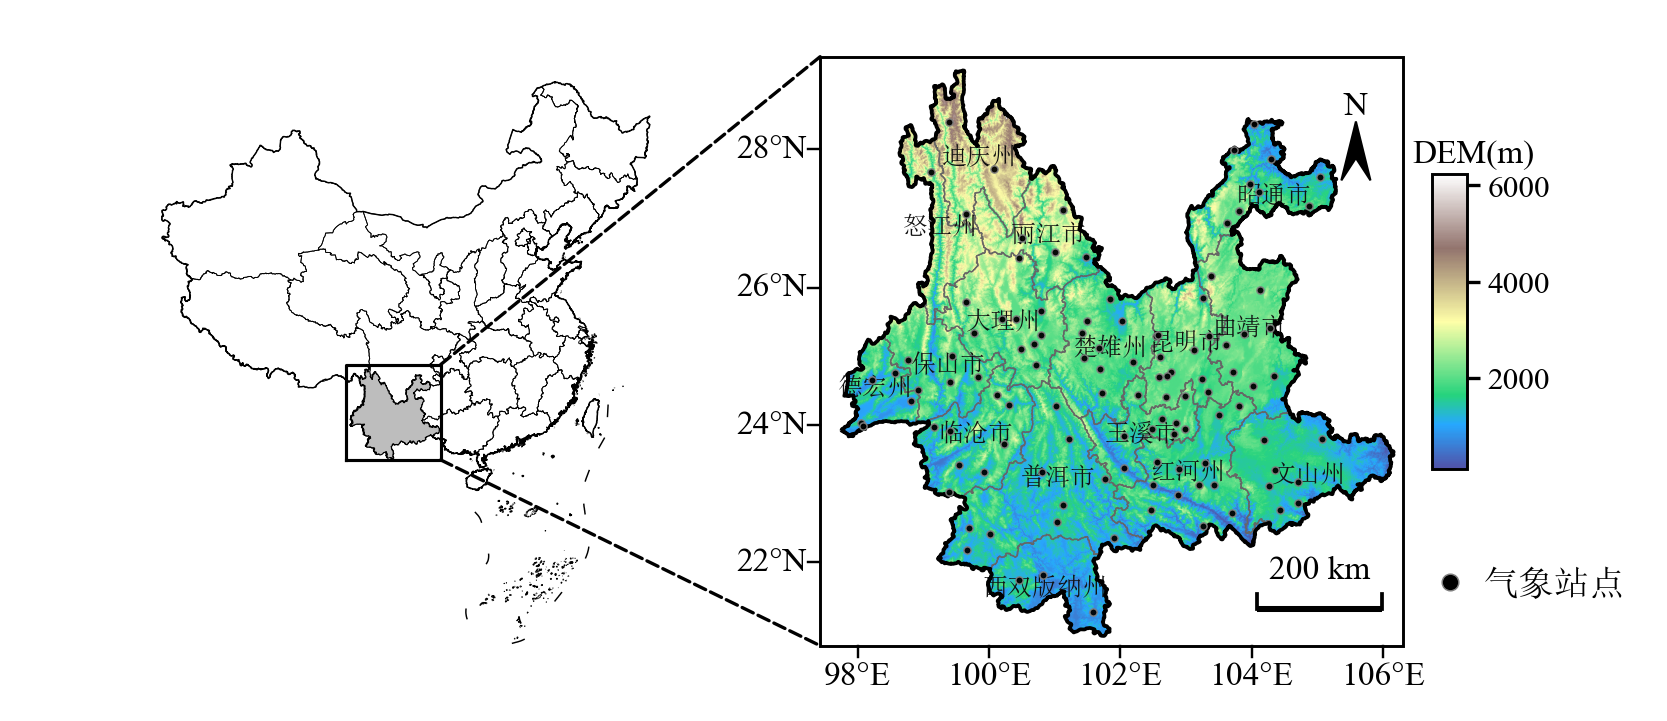

PNG saved to: /content/drive/MyDrive/Drought-monitoring-and-assessment/figures/Fig1_study_area_station_SCI.png
PDF saved to: /content/drive/MyDrive/Drought-monitoring-and-assessment/figures/Fig1_study_area_station_SCI.pdf


In [19]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec

import geopandas as gpd
import pandas as pd
from pathlib import Path
import numpy as np
import re

import cartopy.crs as ccrs
import rasterio
from rasterio.mask import mask


# =====================================================
# 0. 路径设置
# =====================================================
project_dir = Path("/content/drive/MyDrive/Drought-monitoring-and-assessment")
fig_dir = project_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

china_shp = "/content/drive/MyDrive/gis/china/china_province.shp"
cn_outline_shp = "/content/drive/MyDrive/gis/china/中国范围.shp"

yn_shp = "/content/drive/MyDrive/gis/boua_s.shp"      # 云南省界
yn_d_shp = "/content/drive/MyDrive/gis/boua_d.shp"    # 云南州市界

dem_tif = "/content/drive/MyDrive/gis/dem_wgs84.tif"

st_info = (
    "/content/drive/MyDrive/Drought-monitoring-and-assessment/"
    "data/spei/站点编号及信息_选定_1969-2025.xlsx"
)

out_png = fig_dir / "Fig1_study_area_station_SCI.png"
out_pdf = fig_dir / "Fig1_study_area_station_SCI.pdf"


# =====================================================
# 1. 字体设置
# =====================================================
font_dir = Path("/content/drive/MyDrive/fonts")
font_en_path = font_dir / "TimesNewRoman.ttf"
font_zh_path = font_dir / "SimSun.ttf"

if not font_en_path.exists():
    raise FileNotFoundError(f"未找到英文字体: {font_en_path}")
if not font_zh_path.exists():
    raise FileNotFoundError(f"未找到中文字体: {font_zh_path}")

fm.fontManager.addfont(str(font_en_path))
fm.fontManager.addfont(str(font_zh_path))

font_en = fm.FontProperties(fname=str(font_en_path))
font_zh = fm.FontProperties(fname=str(font_zh_path))
font_en_name = font_en.get_name()

mpl.rcParams.update({
    "font.family": font_en_name,
    "font.serif": [font_en_name],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "font.size": 8.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "savefig.facecolor": "white",
    "figure.facecolor": "white"
})


# =====================================================
# 2. 工具函数
# =====================================================
def read_shp_safely(shp_path, target_crs="EPSG:4326", default_crs="EPSG:4326"):
    """
    安全读取 Shapefile。
    关键：只对 Polygon / MultiPolygon 做 buffer(0)，
    不对 LineString 做 buffer(0)，避免线要素被修复为空。
    """
    shp_path = Path(shp_path)

    if not shp_path.exists():
        raise FileNotFoundError(f"未找到矢量文件: {shp_path}")

    encodings = ["utf-8", "GB18030", "GBK"]
    last_error = None

    for enc in encodings:
        try:
            try:
                gdf = gpd.read_file(shp_path, engine="pyogrio", encoding=enc)
            except Exception:
                gdf = gpd.read_file(shp_path, encoding=enc)

            gdf = gdf[
                gdf.geometry.notna() & (~gdf.geometry.is_empty)
            ].copy()

            if gdf.empty:
                raise ValueError(f"{shp_path.name} 读取后为空。")

            if gdf.crs is None:
                print(f"提示：{shp_path.name} 未检测到 CRS，默认设置为 {default_crs}")
                gdf = gdf.set_crs(default_crs)

            gdf = gdf.to_crs(target_crs)

            # 只修复面要素，不修复线要素
            poly_mask = gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
            if poly_mask.any():
                gdf.loc[poly_mask, "geometry"] = (
                    gdf.loc[poly_mask, "geometry"].buffer(0)
                )

            gdf = gdf[
                gdf.geometry.notna() & (~gdf.geometry.is_empty)
            ].copy()

            if gdf.empty:
                raise ValueError(f"{shp_path.name} 几何修复后为空。")

            bounds = np.array(gdf.total_bounds, dtype=float)
            if not np.all(np.isfinite(bounds)):
                raise ValueError(
                    f"{shp_path.name} 的 total_bounds 无效: {bounds}\n"
                    f"几何类型: {gdf.geometry.geom_type.unique()}"
                )

            print(f"成功读取: {shp_path.name}，编码: {enc}")
            print(f"几何类型: {gdf.geometry.geom_type.unique()}")
            print(f"范围: {bounds}")

            return gdf

        except Exception as e:
            last_error = e

    raise RuntimeError(f"读取失败: {shp_path}\n最后一次错误为:\n{last_error}")


def get_valid_bounds(gdf, name="gdf"):
    """
    获取有效边界范围，防止 total_bounds 出现 NaN 或 Inf。
    """
    gdf = gdf[
        gdf.geometry.notna() & (~gdf.geometry.is_empty)
    ].copy()

    if gdf.empty:
        raise ValueError(f"{name} 为空，无法计算范围。")

    bounds = np.array(gdf.total_bounds, dtype=float)

    if not np.all(np.isfinite(bounds)):
        raise ValueError(
            f"{name} 的范围包含 NaN 或 Inf: {bounds}\n"
            f"请检查该 shp 是否为空、缺少几何或 CRS 异常。"
        )

    minx, miny, maxx, maxy = bounds

    if minx >= maxx or miny >= maxy:
        raise ValueError(f"{name} 的范围不合法: {bounds}")

    return minx, miny, maxx, maxy


def projected_aspect(proj, extent, pc):
    """
    根据经纬度 extent 计算投影后的宽高比。
    extent 格式：[lon_min, lon_max, lat_min, lat_max]
    """
    lon_min, lon_max, lat_min, lat_max = extent

    arr = np.array(extent, dtype=float)
    if not np.all(np.isfinite(arr)):
        raise ValueError(f"extent 包含 NaN 或 Inf: {extent}")

    lons = np.array([lon_min, lon_max, lon_max, lon_min])
    lats = np.array([lat_min, lat_min, lat_max, lat_max])

    pts = proj.transform_points(pc, lons, lats)
    xs = pts[:, 0]
    ys = pts[:, 1]

    if (not np.all(np.isfinite(xs))) or (not np.all(np.isfinite(ys))):
        raise ValueError(
            f"投影转换后出现 NaN 或 Inf。\n"
            f"原始 extent = {extent}\n"
            f"xs = {xs}\n"
            f"ys = {ys}"
        )

    width = xs.max() - xs.min()
    height = ys.max() - ys.min()

    if width <= 0 or height <= 0:
        raise ValueError(f"投影后宽高无效: width={width}, height={height}")

    return width / height


def set_map_frame(ax, linewidth=0.7):
    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)
        spine.set_color("black")


def add_panel_label(ax, label, title, font_prop, fontsize=8.8):
    ax.text(
        0.018, 0.982,
        f"{label} {title}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontproperties=font_prop,
        fontsize=fontsize,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.82,
            pad=1.2
        ),
        zorder=100
    )


def add_manual_lonlat_ticks(
    ax,
    xticks,
    yticks,
    extent_lonlat,
    font_prop,
    labelsize=8,
    tick_frac=0.014,
    xpad_frac=0.026,
    ypad_frac=0.022,
    linewidth=0.58,
    pc=None
):
    """
    在投影地图上手动添加经纬度刻度。
    """
    proj = ax.projection

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    xlen = x1 - x0
    ylen = y1 - y0

    tick_len_y = ylen * tick_frac
    tick_len_x = xlen * tick_frac

    lon_min, lon_max, lat_min, lat_max = extent_lonlat

    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # x 轴经度刻度
    ref_lat = lat_min
    for lon in xticks:
        x_tick, _ = proj.transform_point(lon, ref_lat, pc)

        if x0 <= x_tick <= x1:
            ax.plot(
                [x_tick, x_tick],
                [y0, y0 - tick_len_y],
                color="black",
                linewidth=linewidth,
                clip_on=False,
                zorder=90
            )

            ax.text(
                x_tick,
                y0 - ylen * xpad_frac,
                f"{int(lon)}°E",
                ha="center",
                va="top",
                fontproperties=font_prop,
                fontsize=labelsize,
                clip_on=False,
                zorder=91
            )

    # y 轴纬度刻度
    ref_lon = lon_min
    for lat in yticks:
        _, y_tick = proj.transform_point(ref_lon, lat, pc)

        if y0 <= y_tick <= y1:
            ax.plot(
                [x0, x0 - tick_len_x],
                [y_tick, y_tick],
                color="black",
                linewidth=linewidth,
                clip_on=False,
                zorder=90
            )

            ax.text(
                x0 - xlen * ypad_frac,
                y_tick,
                f"{int(lat)}°N",
                ha="right",
                va="center",
                fontproperties=font_prop,
                fontsize=labelsize,
                clip_on=False,
                zorder=91
            )


def add_north(
    ax,
    font_prop,
    labelsize=8,
    loc_x=0.915,
    loc_y=0.962,
    width=0.045,
    height=0.075,
    pad=0.108
):
    """
    添加指北针。
    """
    minx, maxx = ax.get_xlim()
    miny, maxy = ax.get_ylim()

    xlen = maxx - minx
    ylen = maxy - miny

    left = [
        minx + xlen * (loc_x - width * 0.5),
        miny + ylen * (loc_y - pad)
    ]
    right = [
        minx + xlen * (loc_x + width * 0.5),
        miny + ylen * (loc_y - pad)
    ]
    top = [
        minx + xlen * loc_x,
        miny + ylen * (loc_y - pad + height)
    ]
    center = [
        minx + xlen * loc_x,
        left[1] + (top[1] - left[1]) * 0.38
    ]

    triangle = mpatches.Polygon(
        [left, top, right, center],
        facecolor="black",
        edgecolor="black",
        linewidth=0.5,
        zorder=95
    )

    ax.add_patch(triangle)

    ax.text(
        x=minx + xlen * loc_x,
        y=miny + ylen * (loc_y - pad + height),
        s="N",
        fontsize=labelsize,
        fontproperties=font_prop,
        ha="center",
        va="bottom",
        color="black",
        zorder=96
    )


def add_scalebar_albers(
    ax,
    font_prop,
    length_km=200,
    location=(0.075, 0.075),
    linewidth=1.45,
    labelsize=8
):
    """
    在 Albers 投影坐标下添加比例尺。
    """
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    xlen = x1 - x0
    ylen = y1 - y0

    start_x = x0 + xlen * location[0]
    start_y = y0 + ylen * location[1]

    scale_len = length_km * 1000.0
    tick_h = ylen * 0.012

    ax.plot(
        [start_x, start_x + scale_len],
        [start_y - tick_h, start_y - tick_h],
        color="black",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=95
    )

    ax.plot(
        [start_x, start_x],
        [start_y - tick_h, start_y + tick_h],
        color="black",
        linewidth=0.9,
        zorder=95
    )

    ax.plot(
        [start_x + scale_len, start_x + scale_len],
        [start_y - tick_h, start_y + tick_h],
        color="black",
        linewidth=0.9,
        zorder=95
    )

    ax.text(
        start_x + scale_len / 2,
        start_y + tick_h * 2.3,
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=labelsize,
        fontproperties=font_prop,
        color="black",
        zorder=96
    )


def plot_outline_mixed_geometry(
    gdf,
    ax,
    color="black",
    linewidth=0.6,
    zorder=10
):
    """
    同时处理 Polygon / MultiPolygon / LineString / MultiLineString。
    """
    geom_type = gdf.geometry.geom_type

    poly_gdf = gdf[
        geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()

    line_gdf = gdf[
        geom_type.isin(["LineString", "MultiLineString"])
    ].copy()

    if not poly_gdf.empty:
        poly_gdf.boundary.plot(
            ax=ax,
            color=color,
            linewidth=linewidth,
            zorder=zorder
        )

    if not line_gdf.empty:
        line_gdf.plot(
            ax=ax,
            color=color,
            linewidth=linewidth,
            zorder=zorder
        )


def simplify_name(name):
    """
    简化云南州市名称。
    """
    name = str(name).replace("聽", "").strip()

    name = re.sub(
        r"(彝族|白族|傣族|景颇族|藏族|哈尼族|傈僳族|壮族|苗族|自治)+",
        "",
        name
    )

    return name


def read_station_excel(st_info_path, yn_gdf):
    """
    读取站点 Excel，自动识别经纬度字段，并筛选云南省范围内站点。
    """
    st_info_path = Path(st_info_path)

    if not st_info_path.exists():
        raise FileNotFoundError(f"未找到站点信息文件: {st_info_path}")

    st_df = pd.read_excel(st_info_path)

    print("站点字段名：")
    print(list(st_df.columns))
    print(st_df.head())

    lon_col = None
    lat_col = None

    lon_candidates = [
        "lon", "longitude", "lng",
        "经度", "经度/e", "longitude/e", "x"
    ]

    lat_candidates = [
        "lat", "latitude",
        "纬度", "纬度/n", "latitude/n", "y"
    ]

    for col in st_df.columns:
        c = str(col).strip().lower()

        if c in lon_candidates and lon_col is None:
            lon_col = col

        if c in lat_candidates and lat_col is None:
            lat_col = col

    # 包含式匹配
    if lon_col is None:
        for col in st_df.columns:
            c = str(col).strip().lower()

            if ("lon" in c) or ("经度" in c) or ("lng" in c):
                lon_col = col
                break

    if lat_col is None:
        for col in st_df.columns:
            c = str(col).strip().lower()

            if ("lat" in c) or ("纬度" in c):
                lat_col = col
                break

    if lon_col is None or lat_col is None:
        raise ValueError(
            f"未能识别经纬度字段。\n"
            f"当前字段为: {list(st_df.columns)}"
        )

    print(f"识别到经度字段: {lon_col}")
    print(f"识别到纬度字段: {lat_col}")

    # 转为数值，避免 Excel 读入字符串或异常字符
    st_df[lon_col] = pd.to_numeric(st_df[lon_col], errors="coerce")
    st_df[lat_col] = pd.to_numeric(st_df[lat_col], errors="coerce")

    st_df = st_df.dropna(subset=[lon_col, lat_col]).copy()

    station_gdf = gpd.GeoDataFrame(
        st_df,
        geometry=gpd.points_from_xy(st_df[lon_col], st_df[lat_col]),
        crs="EPSG:4326"
    )

    try:
        yn_union = yn_gdf.geometry.union_all()
    except AttributeError:
        yn_union = yn_gdf.geometry.unary_union

    station_gdf = station_gdf[
        station_gdf.geometry.intersects(yn_union)
    ].copy()

    print(f"云南省范围内气象站点数量: {len(station_gdf)}")

    return station_gdf


# =====================================================
# 3. 读取矢量和站点数据
# =====================================================
china_gdf = read_shp_safely(china_shp)
cn_outline_gdf = read_shp_safely(cn_outline_shp)
yn_gdf = read_shp_safely(yn_shp)
yn_d_gdf = read_shp_safely(yn_d_shp)

station_gdf = read_station_excel(st_info, yn_gdf)


# =====================================================
# 4. 投影设置
# =====================================================
proj_albers = ccrs.AlbersEqualArea(
    central_longitude=105,
    central_latitude=35,
    standard_parallels=(25, 47)
)

pc = ccrs.PlateCarree()

albers_crs = (
    "+proj=aea +lat_0=35 +lon_0=105 "
    "+lat_1=25 +lat_2=47 "
    "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

china_gdf_albers = china_gdf.to_crs(albers_crs)
cn_outline_albers = cn_outline_gdf.to_crs(albers_crs)

yn_gdf_albers = yn_gdf.to_crs(albers_crs)
yn_d_gdf_albers = yn_d_gdf.to_crs(albers_crs)

station_gdf_albers = station_gdf.to_crs(albers_crs)


# =====================================================
# 5. 地图范围设置
# =====================================================
# 中国范围：优先使用 中国范围.shp
try:
    cn_minx, cn_miny, cn_maxx, cn_maxy = get_valid_bounds(
        cn_outline_gdf,
        name="中国范围.shp"
    )
except Exception as e:
    print("⚠️ 中国范围.shp 范围无效，改用 china_province.shp 范围。")
    print(e)

    cn_minx, cn_miny, cn_maxx, cn_maxy = get_valid_bounds(
        china_gdf,
        name="china_province.shp"
    )

china_buffer = 3.0

china_extent = [
    cn_minx,
    cn_maxx,
    cn_miny - china_buffer,
    cn_maxy + china_buffer
]

# 兜底：中国常用范围，包含南海区域
if not np.all(np.isfinite(np.array(china_extent, dtype=float))):
    china_extent = [73, 136, 3, 54]

print("china_extent =", china_extent)


# 云南范围
minx, miny, maxx, maxy = get_valid_bounds(
    yn_gdf,
    name="云南省界"
)

yn_buffer = 0.10

yn_extent = [
    minx - yn_buffer,
    maxx + yn_buffer,
    miny - yn_buffer,
    maxy + yn_buffer
]

print("yn_extent =", yn_extent)


# =====================================================
# 6. 创建画布
# =====================================================
china_aspect = projected_aspect(proj_albers, china_extent, pc)
yn_aspect = projected_aspect(proj_albers, yn_extent, pc)

fig = plt.figure(
    figsize=(5.0, 3.0),
    dpi=300,
    facecolor="white"
)

gs = GridSpec(
    1,
    2,
    figure=fig,
    left=0.070,
    right=0.985,
    bottom=0.05,
    top=0.95,
    wspace=0.02,
    width_ratios=[china_aspect, yn_aspect]
)

ax1 = fig.add_subplot(gs[0, 0], projection=proj_albers)
ax2 = fig.add_subplot(gs[0, 1], projection=proj_albers)


# =====================================================
# 7. 子图1：中国范围内研究区位置
# =====================================================
ax1.set_extent(china_extent, crs=pc)

# 中国外边界，包括南海诸岛取决于 中国范围.shp 是否包含对应要素
plot_outline_mixed_geometry(
    cn_outline_albers,
    ax=ax1,
    color="black",
    linewidth=0.35,
    zorder=7
)

# 省界
china_gdf_albers.boundary.plot(
    ax=ax1,
    edgecolor="black",
    linewidth=0.20,
    zorder=2
)

# 高亮云南
yn_gdf_albers.plot(
    ax=ax1,
    facecolor="#bdbdbd",
    edgecolor="black",
    linewidth=0.25,
    zorder=8
)

ax1.set_extent(china_extent, crs=pc)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.set_xticks([])
ax1.set_yticks([])




# =====================================================
# 8. 子图2：云南研究区与气象站点
# =====================================================
ax2.set_extent(yn_extent, crs=pc)

# 8.1 DEM 裁剪与显示
with rasterio.open(dem_tif) as src:
    out_image, out_transform = mask(
        src,
        yn_gdf.geometry,
        crop=True,
        filled=False
    )

    dem_data = out_image[0]

    b = rasterio.transform.array_bounds(
        out_image.shape[1],
        out_image.shape[2],
        out_transform
    )

    dem_extent = [b[0], b[2], b[1], b[3]]

img = ax2.imshow(
    dem_data,
    extent=dem_extent,
    transform=pc,
    cmap="terrain",
    origin="upper",
    zorder=1.5,
    alpha=0.85
)

# 8.2 州市边界
yn_d_gdf_albers.plot(
    ax=ax2,
    facecolor="none",
    edgecolor="#666666",
    linewidth=0.32,
    zorder=2
)
yn_gdf_albers.boundary.plot(
    ax=ax2,
    edgecolor="black",
    linewidth=0.90,
    zorder=5
)

# 8.4 气象站点
station_gdf_albers.plot(
    ax=ax2,
    marker="o",
    markersize=3,
    facecolor="black",
    edgecolor="gray",
    linewidth=0.35,
    alpha=0.95,
    zorder=8
)

ax2.set_extent(yn_extent, crs=pc)
set_map_frame(ax2, linewidth=0.70)

# =====================================================
# 8.5 手动经纬度刻度
# =====================================================
fig.canvas.draw()

add_manual_lonlat_ticks(
    ax=ax2,
    xticks=[98, 100, 102, 104, 106],
    yticks=[22, 24, 26, 28],
    extent_lonlat=yn_extent,
    font_prop=font_en,
    labelsize=8,
    tick_frac=0.020,
    xpad_frac=0.026,
    ypad_frac=0.022,
    linewidth=0.58,
    pc=pc
)

# =====================================================
# 8.6 DEM 色标
# =====================================================
cax = ax2.inset_axes([1.05, 0.30, 0.06, 0.50])

cbar = plt.colorbar(
    img,
    cax=cax,
    orientation="vertical"
)

cbar.ax.set_title(
    "DEM(m)",
    fontproperties=font_en,
    fontsize=8,
    pad=3,
    x=1.2,
    loc="center"
)

cbar.ax.tick_params(length=3, pad=2)

for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(font_en)
    label.set_fontsize(7.5)


# =====================================================
# 8.7 州市名称
# =====================================================
name_col = None

for col in [
    "州市名", "NAME", "name", "Name",
    "市", "地州市", "CNTY_NM", "市名", "CITY"
]:
    if col in yn_d_gdf_albers.columns:
        name_col = col
        break

if name_col:
    for _, row in yn_d_gdf_albers.iterrows():
        if row.geometry is not None and not row.geometry.is_empty:
            pt = row.geometry.representative_point()
            short_name = simplify_name(row[name_col])

            ax2.text(
                pt.x,
                pt.y,
                short_name,
                ha="center",
                va="center",
                fontproperties=font_zh,
                fontweight="bold",
                fontsize=6,
                color="#111111",
                zorder=4
            )
else:
    print(f"⚠️ 未找到州市名称字段。当前字段有: {list(yn_d_gdf_albers.columns)}")


# =====================================================
# 8.8 指北针、比例尺、标题
# =====================================================
add_north(
    ax=ax2,
    font_prop=font_en,
    labelsize=8,
    loc_x=0.92,
    loc_y=0.80,
    width=0.05,
    height=0.10,
    pad=0.01
)

add_scalebar_albers(
    ax=ax2,
    font_prop=font_en,
    length_km=200,
    location=(0.75, 0.075),
    linewidth=1.45,
    labelsize=8
)


# =====================================================
# 8.9 气象站点图例
# =====================================================
station_handle = mlines.Line2D(
    [],
    [],
    color="none",
    marker="o",
    markerfacecolor="black",
    markeredgecolor="gray",
    markeredgewidth=0.35,
    markersize=4,
    label="气象站点"
)

leg = ax2.legend(
    handles=[station_handle],
    loc="lower left",
    bbox_to_anchor=(1, 0.03),
    frameon=False,
    fontsize=7.5,
    prop=font_zh,
    handlelength=1.0,
    handletextpad=0.45,
    borderpad=0.35
)

leg.get_frame().set_linewidth(0.45)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.88)


# =====================================================
# 9. 左图绘制云南范围框与连线
# =====================================================
fig.canvas.draw()

ax2_x0, ax2_x1 = ax2.get_xlim()
ax2_y0, ax2_y1 = ax2.get_ylim()

bbox_x = [ax2_x0, ax2_x1, ax2_x1, ax2_x0, ax2_x0]
bbox_y = [ax2_y0, ax2_y0, ax2_y1, ax2_y1, ax2_y0]

ax1.plot(
    bbox_x,
    bbox_y,
    color="black",
    linewidth=0.75,
    zorder=10
)

con_top = mpatches.ConnectionPatch(
    xyA=(ax2_x1, ax2_y1),
    xyB=(0, 1),
    coordsA="data",
    coordsB="axes fraction",
    axesA=ax1,
    axesB=ax2,
    color="black",
    linewidth=0.8,
    linestyle="--",
    zorder=100,
    clip_on=False
)

con_bottom = mpatches.ConnectionPatch(
    xyA=(ax2_x1, ax2_y0),
    xyB=(0, 0),
    coordsA="data",
    coordsB="axes fraction",
    axesA=ax1,
    axesB=ax2,
    color="black",
    linewidth=0.8,
    linestyle="--",
    zorder=100,
    clip_on=False
)

ax1.add_artist(con_top)
ax1.add_artist(con_bottom)


# =====================================================
# 10. 保存
# =====================================================
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf, dpi=600, bbox_inches="tight")
plt.show()

print(f"PNG saved to: {out_png}")
print(f"PDF saved to: {out_pdf}")